# 02d — IMD 2025 Sub-Domain Deep Dive

**Purpose:** Explore every IMD domain and sub-domain in depth.
The top-level IMD score is a composite — the sub-domains reveal
the specific mechanisms of deprivation that matter for bus policy.

**Critical for Aequitas:**
- **Geographical Barriers** sub-domain = distance to services (GP, school, post office, supermarket)
  → Direct proxy for Factor 7 (gender-adjusted accessibility)
- **IDACI** (children in income deprivation) → Factor 7 (childcare/school access)
- **IDAOPI** (older people in income deprivation) → Factor 4 (elderly)
- **Employment domain** → Factor 2 (unemployment)
- **Income domain** → Factor 5 (income levels)

**All 56 columns examined, classified, and interpreted for policy.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

RAW = Path('/Users/souravamseekarmarti/Projects/aequitas/data/raw')

imd = pd.read_csv(RAW / 'imd' / 'imd2025_all_ranks_scores_deciles.csv')
print(f"IMD 2025: {len(imd):,} rows × {len(imd.columns)} columns")
print(f"\nAll columns:")
for i, c in enumerate(imd.columns):
    print(f"  [{i:2d}] {c}")

IMD 2025: 33,755 rows × 56 columns

All columns:
  [ 0] LSOA code (2021)
  [ 1] LSOA name (2021)
  [ 2] Local Authority District code (2024)
  [ 3] Local Authority District name (2024)
  [ 4] Index of Multiple Deprivation (IMD) Score
  [ 5] Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)
  [ 6] Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)
  [ 7] Income Score (rate)
  [ 8] Income Rank (where 1 is most deprived)
  [ 9] Income Decile (where 1 is most deprived 10% of LSOAs)
  [10] Employment Score (rate)
  [11] Employment Rank (where 1 is most deprived)
  [12] Employment Decile (where 1 is most deprived 10% of LSOAs)
  [13] Education, Skills and Training Score
  [14] Education, Skills and Training Rank (where 1 is most deprived)
  [15] Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)
  [16] Health Deprivation and Disability Score
  [17] Health Deprivation and Disability Rank (where 1 is most deprived)
  

## Column Taxonomy

The 56 columns follow a pattern: `<Domain/Index> <Metric Type>`
where Metric Type is one of: Score, Rank, Decile

Let's parse this systematically.

In [2]:
# Classify every column
taxonomy = []
for c in imd.columns:
    col_lower = c.lower()
    if 'lsoa' in col_lower and 'code' in col_lower:
        taxonomy.append({'column': c, 'category': 'Identifier', 'metric_type': 'code', 'domain': 'ID'})
    elif 'lsoa' in col_lower and 'name' in col_lower:
        taxonomy.append({'column': c, 'category': 'Identifier', 'metric_type': 'name', 'domain': 'ID'})
    elif 'population' in col_lower:
        taxonomy.append({'column': c, 'category': 'Metadata', 'metric_type': 'population', 'domain': 'Population'})
    elif 'decile' in col_lower:
        domain = c.split('Decile')[0].strip().replace(' -', '').strip()
        taxonomy.append({'column': c, 'category': 'Decile', 'metric_type': 'decile', 'domain': domain})
    elif 'rank' in col_lower:
        domain = c.split('Rank')[0].strip().replace(' -', '').strip()
        taxonomy.append({'column': c, 'category': 'Rank', 'metric_type': 'rank', 'domain': domain})
    elif 'score' in col_lower:
        domain = c.split('Score')[0].strip().replace(' -', '').strip()
        taxonomy.append({'column': c, 'category': 'Score', 'metric_type': 'score', 'domain': domain})
    else:
        taxonomy.append({'column': c, 'category': 'Other', 'metric_type': 'unknown', 'domain': 'unknown'})

tax_df = pd.DataFrame(taxonomy)
print("=== Column Taxonomy ===")
print(f"\nBy category:")
print(tax_df['category'].value_counts().to_string())
print(f"\nBy domain:")
print(tax_df['domain'].value_counts().to_string())

# Show all score columns — these are the ones we'll analyze
score_cols = tax_df[tax_df['metric_type'] == 'score']['column'].tolist()
rank_cols = tax_df[tax_df['metric_type'] == 'rank']['column'].tolist()
decile_cols = tax_df[tax_df['metric_type'] == 'decile']['column'].tolist()

print(f"\n=== Score Columns ({len(score_cols)}) ===")
for c in score_cols:
    print(f"  {c}: [{imd[c].min():.4f}, {imd[c].max():.4f}], mean={imd[c].mean():.4f}")

=== Column Taxonomy ===

By category:
category
Score         16
Rank          16
Decile        16
Other          3
Metadata       3
Identifier     2

By domain:
domain
unknown                                                3
Index of Multiple Deprivation (IMD)                    3
Income                                                 3
Employment                                             3
Education, Skills and Training                         3
Health Deprivation and Disability                      3
Crime                                                  3
Barriers to Housing and Services                       3
Living Environment                                     3
Income Deprivation Affecting Children Index (IDACI)    3
Income Deprivation Affecting Older People (IDAOPI)     3
Children and Young People Sub-domain                   3
Adult Skills Sub-domain                                3
Geographical Barriers Sub-domain                       3
Wider Barriers Sub-domain         

## 1. Composite IMD Score — The Master Index

Weighted combination of 7 domains. Higher score = more deprived.

=== Composite IMD ===
  Index of Multiple Deprivation (IMD) Score: [0.165, 94.223], mean=21.67
  Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived): [1, 33755], mean=16878.00
  Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs): [1, 10], mean=5.50


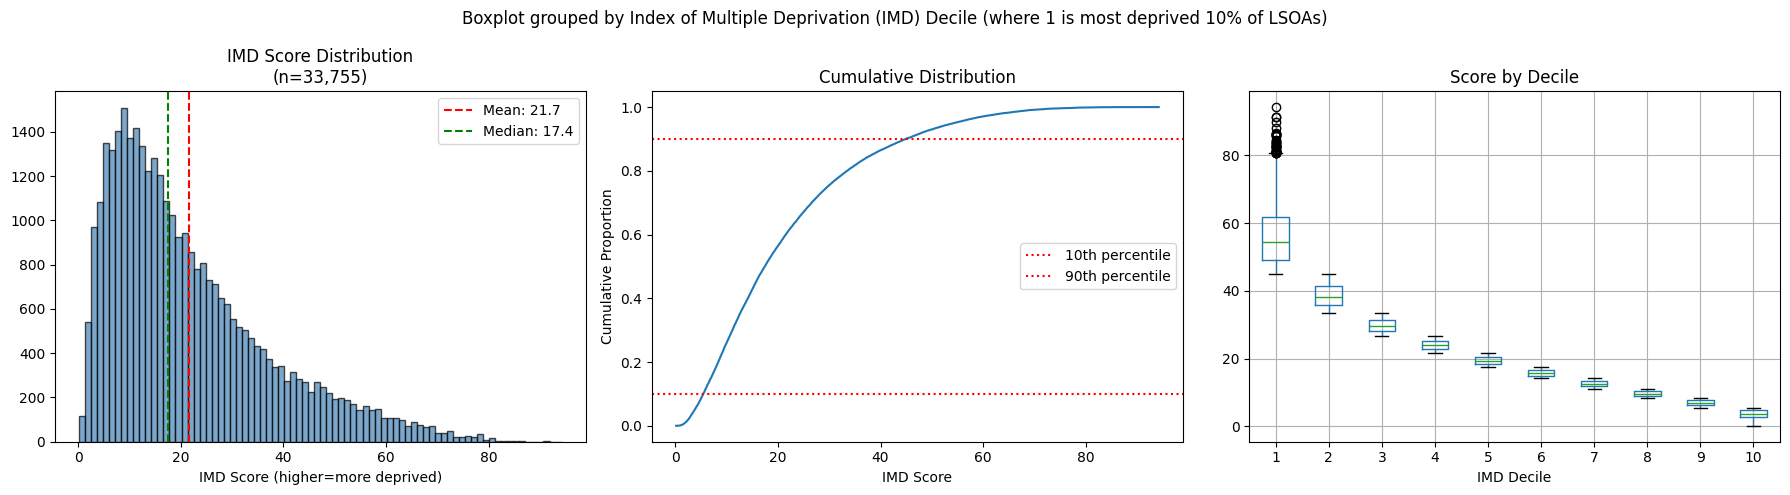

In [3]:
# Find the composite IMD columns
imd_score = [c for c in score_cols if c.startswith('Index of Multiple') or (c.startswith('IMD') and 'sub' not in c.lower())]
imd_rank_c = [c for c in rank_cols if c.startswith('Index of Multiple') or c.startswith('IMD')]
imd_decile_c = [c for c in decile_cols if c.startswith('Index of Multiple') or c.startswith('IMD')]

print("=== Composite IMD ===")
for c in imd_score + imd_rank_c + imd_decile_c:
    print(f"  {c}: [{imd[c].min()}, {imd[c].max()}], mean={imd[c].mean():.2f}")

if imd_score:
    s = imd[imd_score[0]]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].hist(s, bins=80, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].set_title(f'IMD Score Distribution\n(n={len(s):,})')
    axes[0].set_xlabel('IMD Score (higher=more deprived)')
    axes[0].axvline(s.mean(), color='red', linestyle='--', label=f'Mean: {s.mean():.1f}')
    axes[0].axvline(s.median(), color='green', linestyle='--', label=f'Median: {s.median():.1f}')
    axes[0].legend()

    # CDF
    sorted_s = np.sort(s)
    axes[1].plot(sorted_s, np.arange(1, len(sorted_s)+1) / len(sorted_s))
    axes[1].set_title('Cumulative Distribution')
    axes[1].set_xlabel('IMD Score')
    axes[1].set_ylabel('Cumulative Proportion')
    axes[1].axhline(0.1, color='r', linestyle=':', label='10th percentile')
    axes[1].axhline(0.9, color='r', linestyle=':', label='90th percentile')
    axes[1].legend()

    # By decile
    if imd_decile_c:
        imd.boxplot(column=imd_score[0], by=imd_decile_c[0], ax=axes[2])
        axes[2].set_title('Score by Decile')
        axes[2].set_xlabel('IMD Decile')

    plt.tight_layout()
    plt.show()

## 2. The 7 Domains — Individual Profiles

Each domain measures a different aspect of deprivation. The weights are:
- Income: 22.5%
- Employment: 22.5%
- Education: 13.5%
- Health: 13.5%
- Crime: 9.3%
- Barriers: 9.3%
- Living Environment: 9.3%

In [4]:
# Identify the 7 main domain score columns
domain_keywords = {
    'Income': 'income',
    'Employment': 'employment',
    'Education': 'education',
    'Health': 'health',
    'Crime': 'crime',
    'Barriers': 'barrier',
    'Living Environment': 'living',
}

domain_cols = {}
for name, kw in domain_keywords.items():
    candidates = [c for c in score_cols if kw in c.lower()
                  and 'sub' not in c.lower()
                  and 'children' not in c.lower()
                  and 'adult' not in c.lower()
                  and 'geographical' not in c.lower()
                  and 'wider' not in c.lower()
                  and 'indoor' not in c.lower()
                  and 'outdoor' not in c.lower()
                  and 'IDACI' not in c
                  and 'IDAOPI' not in c]
    if candidates:
        domain_cols[name] = candidates[0]
        print(f"{name}: {candidates[0]}")
    else:
        # Fallback: try broader match
        candidates = [c for c in score_cols if kw in c.lower()]
        if candidates:
            domain_cols[name] = candidates[0]
            print(f"{name} (broad match): {candidates[0]}")

Income: Income Score (rate)
Employment: Employment Score (rate)
Education: Education, Skills and Training Score
Health: Health Deprivation and Disability Score
Crime: Crime Score
Barriers: Barriers to Housing and Services Score
Living Environment: Living Environment Score


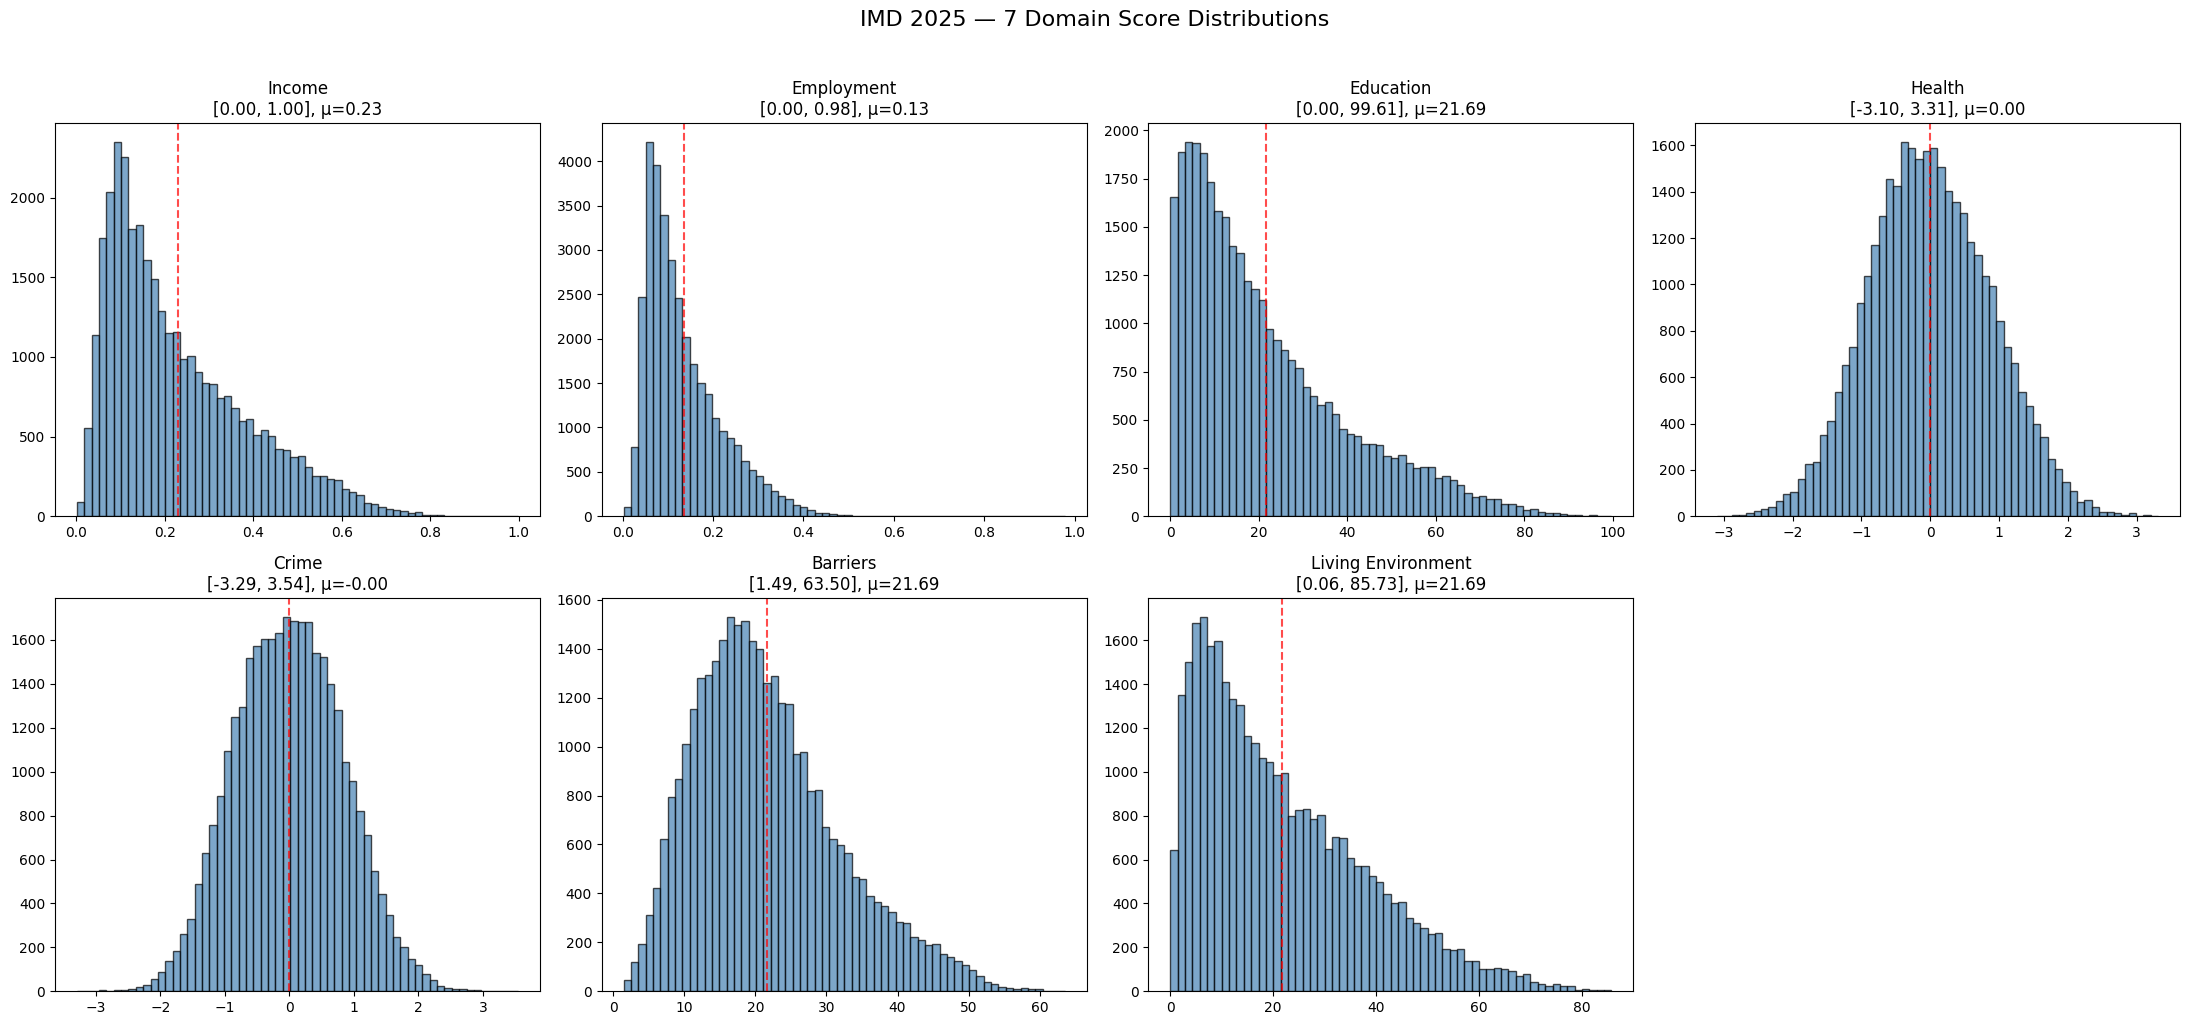

In [5]:
# Profile each domain
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, (name, col) in enumerate(domain_cols.items()):
    if i >= len(axes):
        break
    s = imd[col]
    axes[i].hist(s, bins=60, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_title(f'{name}\n[{s.min():.2f}, {s.max():.2f}], μ={s.mean():.2f}')
    axes[i].axvline(s.mean(), color='red', linestyle='--', alpha=0.7)

# Hide unused subplot
if len(domain_cols) < len(axes):
    for j in range(len(domain_cols), len(axes)):
        axes[j].set_visible(False)

plt.suptitle('IMD 2025 — 7 Domain Score Distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

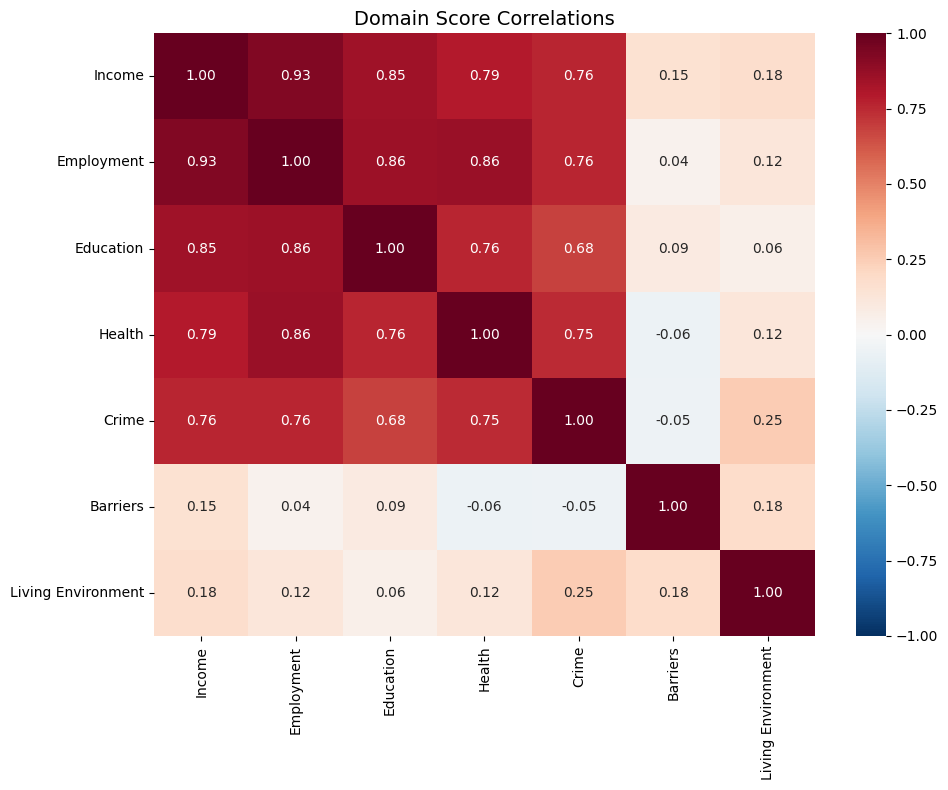

=== Highest Domain Correlations ===
  Income ↔ Employment: r=0.929
  Employment ↔ Health: r=0.862
  Employment ↔ Education: r=0.857
  Income ↔ Education: r=0.846
  Income ↔ Health: r=0.789
  Employment ↔ Crime: r=0.761
  Income ↔ Crime: r=0.761
  Education ↔ Health: r=0.759
  Health ↔ Crime: r=0.748
  Education ↔ Crime: r=0.684
  Crime ↔ Living Environment: r=0.254
  Barriers ↔ Living Environment: r=0.181
  Income ↔ Living Environment: r=0.177
  Income ↔ Barriers: r=0.149
  Employment ↔ Living Environment: r=0.124
  Health ↔ Living Environment: r=0.123
  Education ↔ Barriers: r=0.091
  Education ↔ Living Environment: r=0.062
  Health ↔ Barriers: r=-0.061
  Crime ↔ Barriers: r=-0.048
  Employment ↔ Barriers: r=0.042


In [6]:
# Domain correlations — which domains co-vary?
if len(domain_cols) >= 2:
    domain_df = imd[[c for c in domain_cols.values()]].copy()
    domain_df.columns = list(domain_cols.keys())

    fig, ax = plt.subplots(figsize=(10, 8))
    corr = domain_df.corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
                vmin=-1, vmax=1)
    ax.set_title('Domain Score Correlations', fontsize=14)
    plt.tight_layout()
    plt.show()

    print("=== Highest Domain Correlations ===")
    corr_pairs = []
    for i in range(len(corr)):
        for j in range(i+1, len(corr)):
            corr_pairs.append((corr.index[i], corr.columns[j], corr.iloc[i, j]))
    corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
    for a, b, r in corr_pairs:
        print(f"  {a} ↔ {b}: r={r:.3f}")

## 3. Sub-Domains — The Crucial Detail

The Barriers and Education domains have sub-domains that are
directly relevant to our 8 factors.

In [7]:
# Find all sub-domain score columns
subdomain_cols = {}
subdomain_patterns = {
    'Geographical Barriers': 'geographical',
    'Wider Barriers': 'wider',
    'Children & Young People': 'children',
    'Adult Skills': 'adult',
    'Indoors': 'indoor',
    'Outdoors': 'outdoor',
}

for name, pattern in subdomain_patterns.items():
    candidates = [c for c in score_cols if pattern in c.lower()]
    if candidates:
        subdomain_cols[name] = candidates[0]
        s = imd[candidates[0]]
        print(f"{name}: {candidates[0]}")
        print(f"  Range: [{s.min():.4f}, {s.max():.4f}]")
        print(f"  Mean: {s.mean():.4f}, Std: {s.std():.4f}")
        print(f"  Skew: {s.skew():.2f}, Kurtosis: {s.kurtosis():.2f}")

Geographical Barriers: Geographical Barriers Sub-domain Score
  Range: [1.1440, 96.8280]
  Mean: 35.4033, Std: 16.6060
  Skew: 0.86, Kurtosis: 0.71
Wider Barriers: Wider Barriers Sub-domain Score
  Range: [-11.2000, 10.1060]
  Mean: -0.0007, Std: 3.0184
  Skew: 0.23, Kurtosis: -0.15
Children & Young People: Income Deprivation Affecting Children Index (IDACI) Score (rate)
  Range: [0.0030, 1.0000]
  Mean: 0.3417, Std: 0.2110
  Skew: 0.66, Kurtosis: -0.33
Adult Skills: Adult Skills Sub-domain Score
  Range: [0.0220, 0.7410]
  Mean: 0.2401, Std: 0.0996
  Skew: 0.66, Kurtosis: 0.17
Indoors: Indoors Sub-domain Score
  Range: [-2.0240, 2.3040]
  Mean: 0.0000, Std: 0.6279
  Skew: 0.25, Kurtosis: -0.30
Outdoors: Outdoors Sub-domain Score
  Range: [-2.5690, 2.7830]
  Mean: 0.0000, Std: 0.7505
  Skew: 0.47, Kurtosis: 0.18


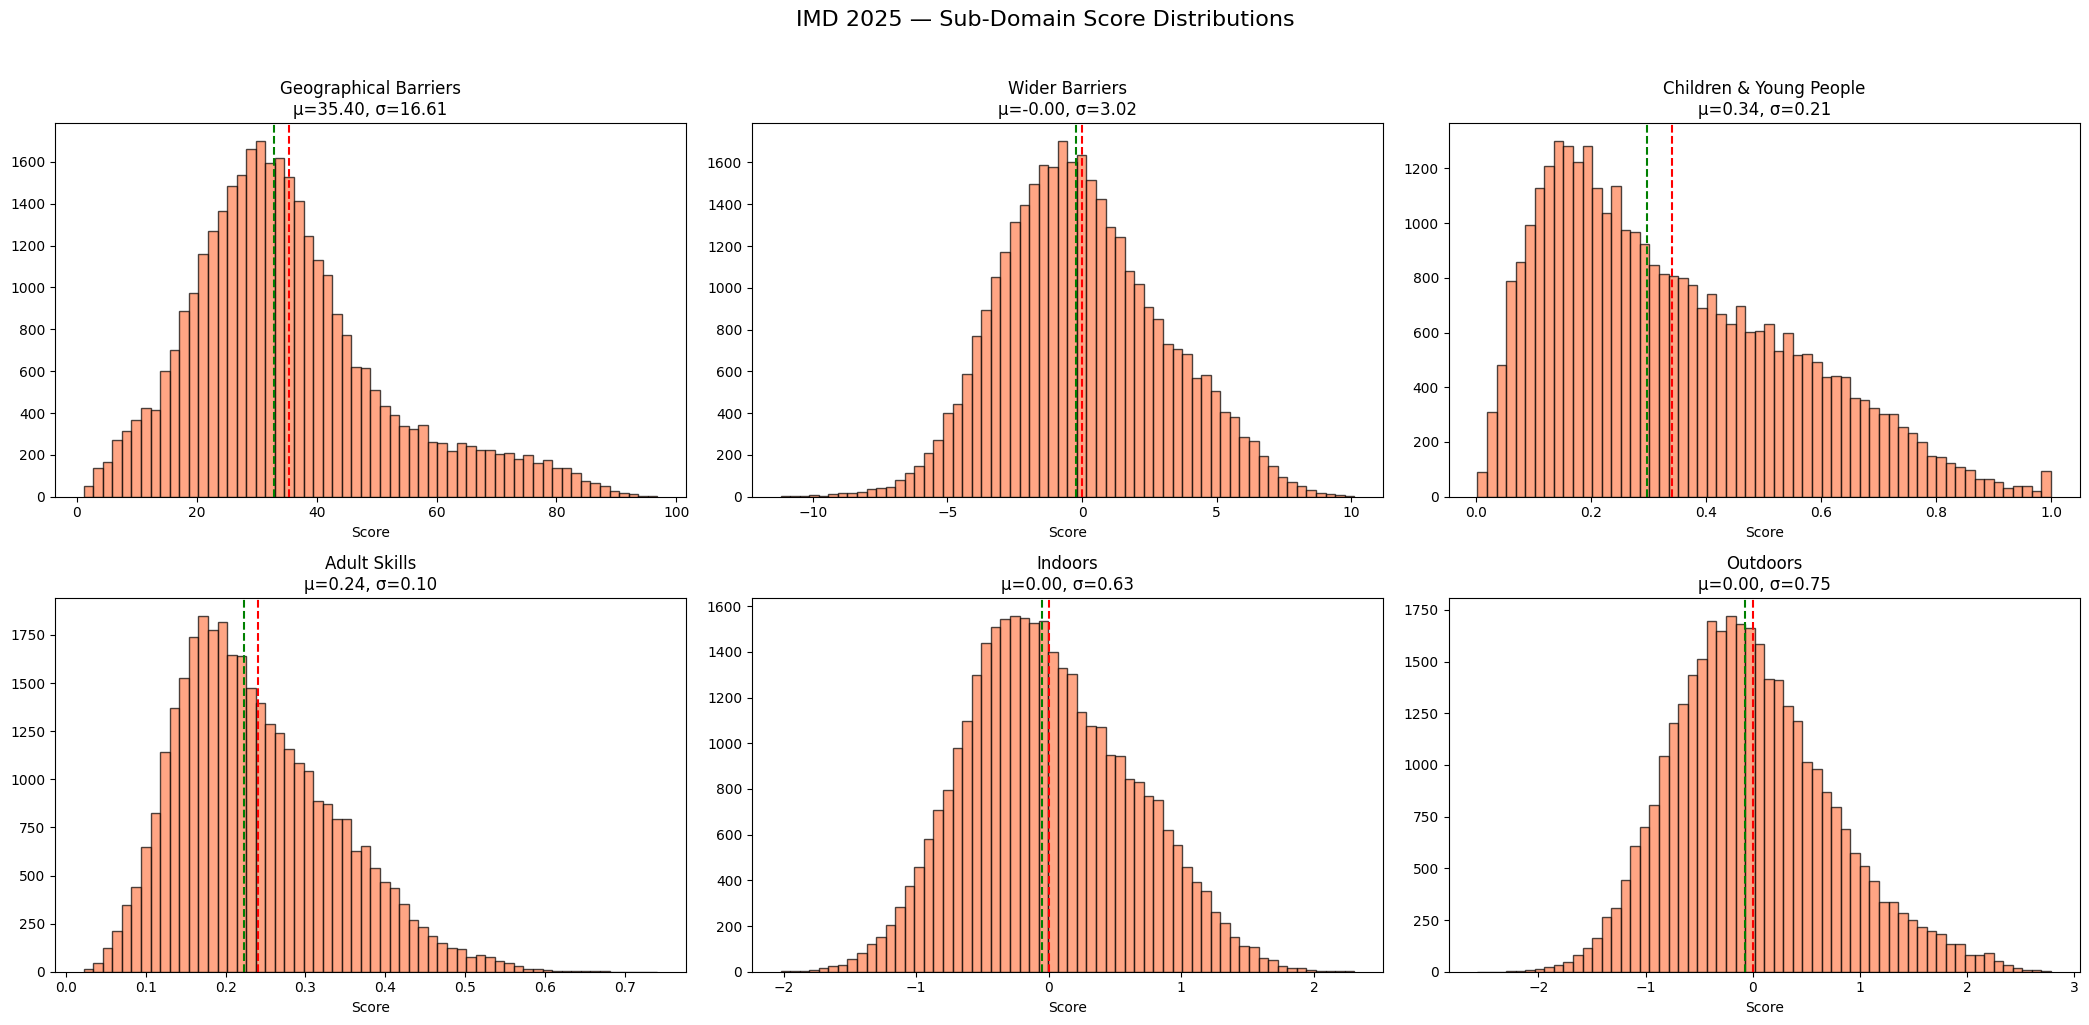

In [8]:
# Sub-domain distributions
if subdomain_cols:
    n_subs = len(subdomain_cols)
    ncols = min(3, n_subs)
    nrows = (n_subs + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 5*nrows))
    if nrows == 1 and ncols == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for i, (name, col) in enumerate(subdomain_cols.items()):
        if i >= len(axes):
            break
        s = imd[col]
        axes[i].hist(s, bins=60, edgecolor='black', alpha=0.7, color='coral')
        axes[i].set_title(f'{name}\nμ={s.mean():.2f}, σ={s.std():.2f}')
        axes[i].set_xlabel('Score')
        axes[i].axvline(s.mean(), color='red', linestyle='--')
        axes[i].axvline(s.median(), color='green', linestyle='--')

    for j in range(len(subdomain_cols), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('IMD 2025 — Sub-Domain Score Distributions', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

## 4. Geographical Barriers — Deep Dive

This sub-domain measures distance to:
- GP surgery
- Primary school
- Post office
- Supermarket/food shop

**This is the single most relevant sub-domain for Aequitas.**
It directly measures what we're trying to correlate with bus coverage.
If an LSOA scores high on geographical barriers AND has few bus stops,
residents are truly cut off from essential services.

=== Geographical Barriers Sub-Domain ===
Score column: Geographical Barriers Sub-domain Score
  Range: [1.1440, 96.8280]
  Percentiles:
    P1: 5.8212
    P5: 12.1627
    P10: 16.9430
    P25: 24.3355
    P50: 32.8510
    P75: 42.9895
    P90: 59.1642
    P95: 70.4445
    P99: 83.1623

Rank column: Geographical Barriers Sub-domain Rank (where 1 is most deprived)
Decile column: Geographical Barriers Sub-domain Decile (where 1 is most deprived 10% of LSOAs)
  Decile distribution:
Geographical Barriers Sub-domain Decile (where 1 is most deprived 10% of LSOAs)
1     3375
2     3376
3     3375
4     3376
5     3375
6     3376
7     3375
8     3376
9     3375
10    3376


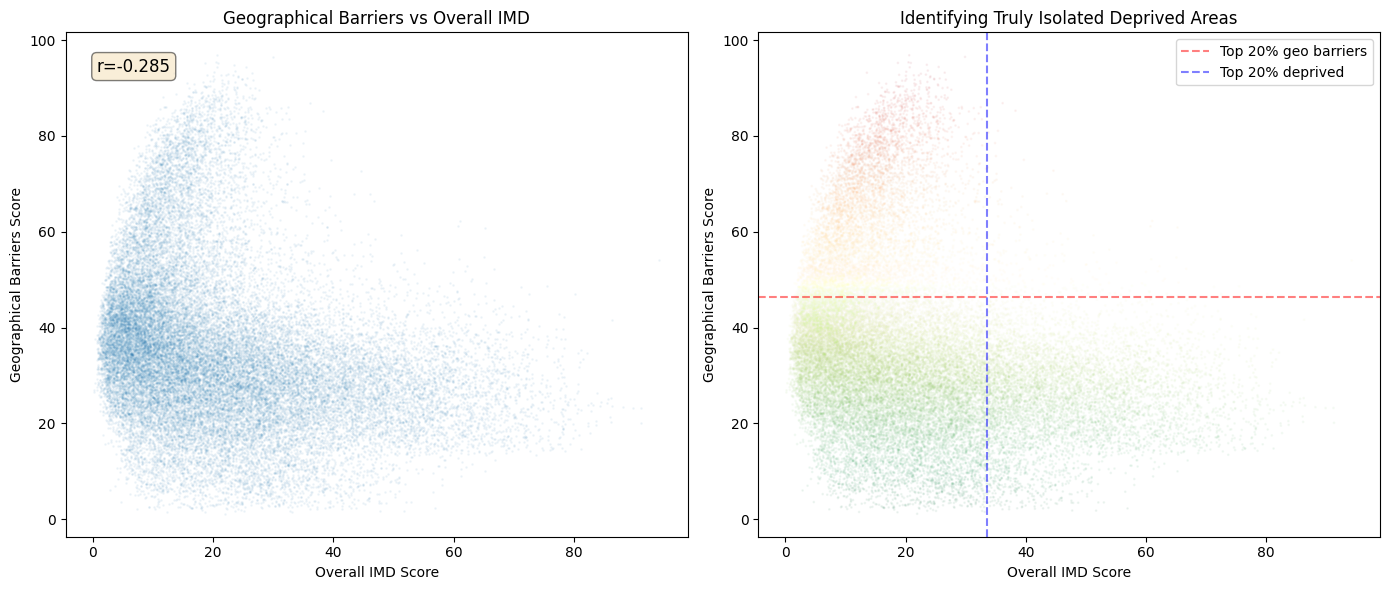


=== Quadrant Analysis ===
  High barriers + High deprivation: 217 LSOAs — CRITICAL PRIORITY
  High barriers + Low deprivation: 6,534 LSOAs — Rural wealthy
  Low barriers + High deprivation: 6,534 LSOAs — Urban deprived
  Low barriers + Low deprivation: 20,470 LSOAs — Well-connected affluent


In [9]:
if 'Geographical Barriers' in subdomain_cols:
    geo_col = subdomain_cols['Geographical Barriers']
    s = imd[geo_col]

    # Also get the corresponding rank and decile
    geo_rank = [c for c in rank_cols if 'geographical' in c.lower()]
    geo_decile = [c for c in decile_cols if 'geographical' in c.lower()]

    print(f"=== Geographical Barriers Sub-Domain ===")
    print(f"Score column: {geo_col}")
    print(f"  Range: [{s.min():.4f}, {s.max():.4f}]")
    print(f"  Percentiles:")
    for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
        print(f"    P{p}: {s.quantile(p/100):.4f}")

    if geo_rank:
        print(f"\nRank column: {geo_rank[0]}")
    if geo_decile:
        print(f"Decile column: {geo_decile[0]}")
        d = imd[geo_decile[0]]
        print(f"  Decile distribution:")
        print(d.value_counts().sort_index().to_string())

    # Geographical Barriers vs overall IMD
    if imd_score:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        axes[0].scatter(imd[imd_score[0]], s, alpha=0.05, s=1)
        axes[0].set_xlabel('Overall IMD Score')
        axes[0].set_ylabel('Geographical Barriers Score')
        axes[0].set_title('Geographical Barriers vs Overall IMD')

        # Correlation
        corr_val = imd[imd_score[0]].corr(s)
        axes[0].text(0.05, 0.95, f'r={corr_val:.3f}', transform=axes[0].transAxes,
                     fontsize=12, verticalalignment='top',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        # Geographical Barriers: high geo barriers but low overall IMD = rural wealthy
        # High geo barriers AND high overall IMD = truly isolated deprived
        axes[1].scatter(imd[imd_score[0]], s, c=s, alpha=0.05, s=1, cmap='RdYlGn_r')
        axes[1].axhline(s.quantile(0.8), color='red', linestyle='--', alpha=0.5, label='Top 20% geo barriers')
        axes[1].axvline(imd[imd_score[0]].quantile(0.8), color='blue', linestyle='--', alpha=0.5, label='Top 20% deprived')
        axes[1].set_xlabel('Overall IMD Score')
        axes[1].set_ylabel('Geographical Barriers Score')
        axes[1].set_title('Identifying Truly Isolated Deprived Areas')
        axes[1].legend()

        plt.tight_layout()
        plt.show()

        # Count the quadrants
        high_geo = s > s.quantile(0.8)
        high_imd = imd[imd_score[0]] > imd[imd_score[0]].quantile(0.8)
        print(f"\n=== Quadrant Analysis ===")
        print(f"  High barriers + High deprivation: {(high_geo & high_imd).sum():,} LSOAs — CRITICAL PRIORITY")
        print(f"  High barriers + Low deprivation: {(high_geo & ~high_imd).sum():,} LSOAs — Rural wealthy")
        print(f"  Low barriers + High deprivation: {(~high_geo & high_imd).sum():,} LSOAs — Urban deprived")
        print(f"  Low barriers + Low deprivation: {(~high_geo & ~high_imd).sum():,} LSOAs — Well-connected affluent")

## 5. IDACI & IDAOPI — Supplementary Indices

- **IDACI**: Income Deprivation Affecting Children Index (% of 0-15 in income-deprived households)
- **IDAOPI**: Income Deprivation Affecting Older People Index (% of 60+ in income-deprived households)

These are supplementary to the main 7 domains — they're computed separately
and have their own scores, ranks, and deciles.

IDACI: [0.0030, 1.0000], mean=0.3417
  Interpretation: an IDACI score of 1.000 means 100.0% of children live in income-deprived households
  National mean: 34.2% of children in income deprivation

IDACOPI: [0.0030, 0.9980], mean=0.2061
  Interpretation: an IDAOPI score of 0.998 means 99.8% of 60+ live in income-deprived households


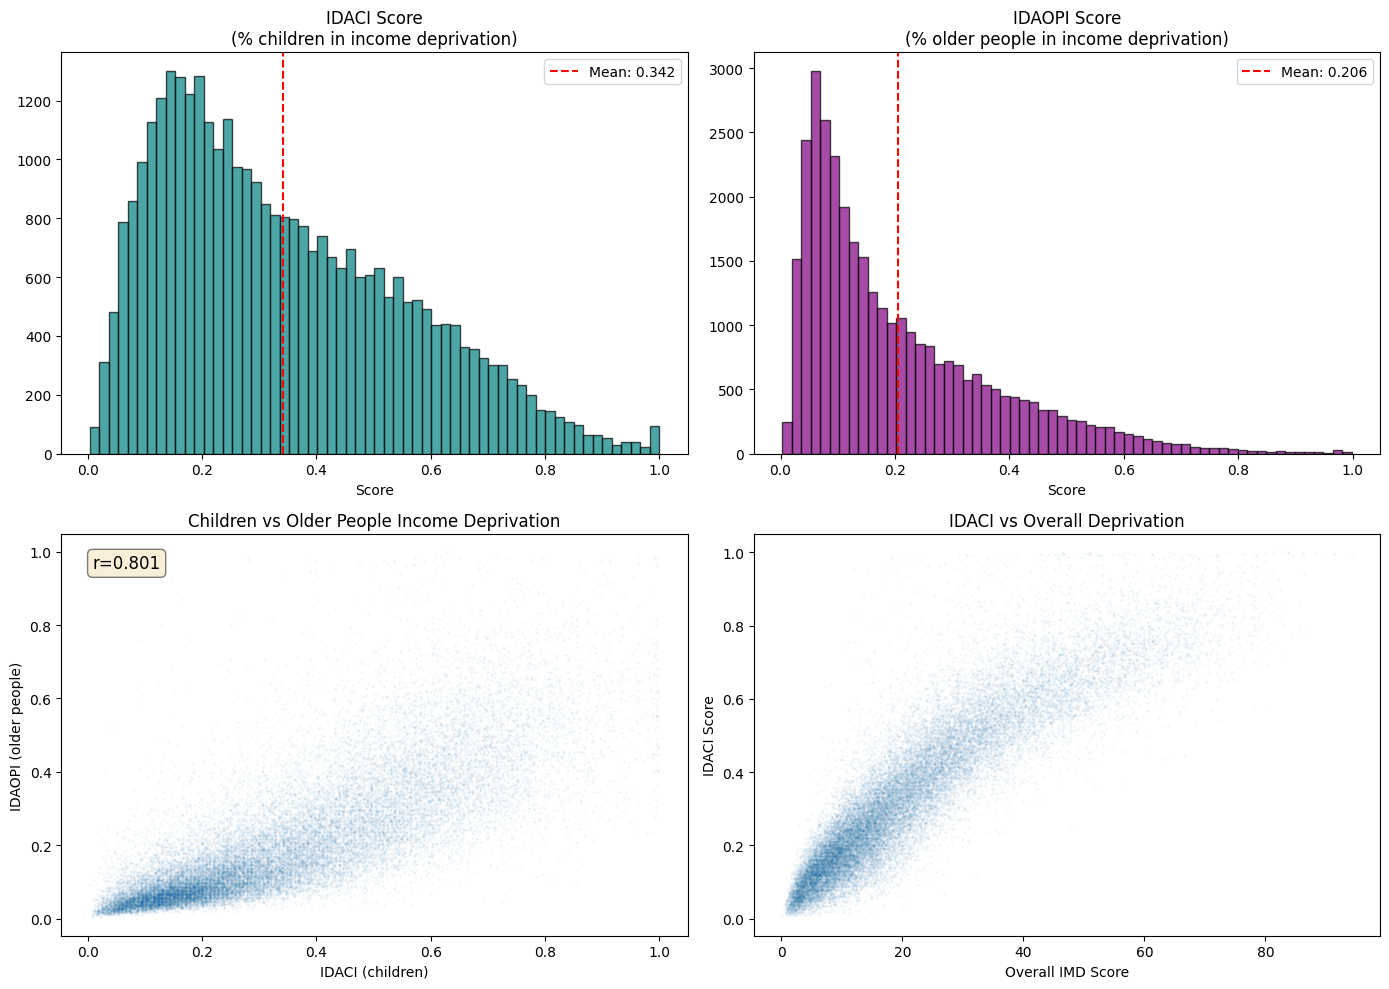

In [10]:
idaci_score = [c for c in score_cols if 'IDACI' in c]
idaopi_score = [c for c in score_cols if 'IDAOPI' in c]
idaci_decile = [c for c in decile_cols if 'IDACI' in c]
idaopi_decile = [c for c in decile_cols if 'IDAOPI' in c]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

if idaci_score:
    s = imd[idaci_score[0]]
    axes[0, 0].hist(s, bins=60, edgecolor='black', alpha=0.7, color='teal')
    axes[0, 0].set_title(f'IDACI Score\n(% children in income deprivation)')
    axes[0, 0].set_xlabel('Score')
    axes[0, 0].axvline(s.mean(), color='red', linestyle='--', label=f'Mean: {s.mean():.3f}')
    axes[0, 0].legend()

    print(f"IDACI: [{s.min():.4f}, {s.max():.4f}], mean={s.mean():.4f}")
    print(f"  Interpretation: an IDACI score of {s.max():.3f} means {s.max()*100:.1f}% of children live in income-deprived households")
    print(f"  National mean: {s.mean()*100:.1f}% of children in income deprivation")

if idaopi_score:
    s = imd[idaopi_score[0]]
    axes[0, 1].hist(s, bins=60, edgecolor='black', alpha=0.7, color='purple')
    axes[0, 1].set_title(f'IDAOPI Score\n(% older people in income deprivation)')
    axes[0, 1].set_xlabel('Score')
    axes[0, 1].axvline(s.mean(), color='red', linestyle='--', label=f'Mean: {s.mean():.3f}')
    axes[0, 1].legend()

    print(f"\nIDACOPI: [{s.min():.4f}, {s.max():.4f}], mean={s.mean():.4f}")
    print(f"  Interpretation: an IDAOPI score of {s.max():.3f} means {s.max()*100:.1f}% of 60+ live in income-deprived households")

# IDACI vs IDAOPI scatter
if idaci_score and idaopi_score:
    axes[1, 0].scatter(imd[idaci_score[0]], imd[idaopi_score[0]], alpha=0.03, s=1)
    axes[1, 0].set_xlabel('IDACI (children)')
    axes[1, 0].set_ylabel('IDAOPI (older people)')
    axes[1, 0].set_title('Children vs Older People Income Deprivation')
    corr_val = imd[idaci_score[0]].corr(imd[idaopi_score[0]])
    axes[1, 0].text(0.05, 0.95, f'r={corr_val:.3f}', transform=axes[1, 0].transAxes,
                     fontsize=12, verticalalignment='top',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# IDACI vs overall IMD
if idaci_score and imd_score:
    axes[1, 1].scatter(imd[imd_score[0]], imd[idaci_score[0]], alpha=0.03, s=1)
    axes[1, 1].set_xlabel('Overall IMD Score')
    axes[1, 1].set_ylabel('IDACI Score')
    axes[1, 1].set_title('IDACI vs Overall Deprivation')

plt.tight_layout()
plt.show()

## 6. Domain vs Domain — What Drives Composite Deprivation?

Not all domains contribute equally. Some areas are income-deprived but
not health-deprived. Understanding these profiles matters for policy targeting.

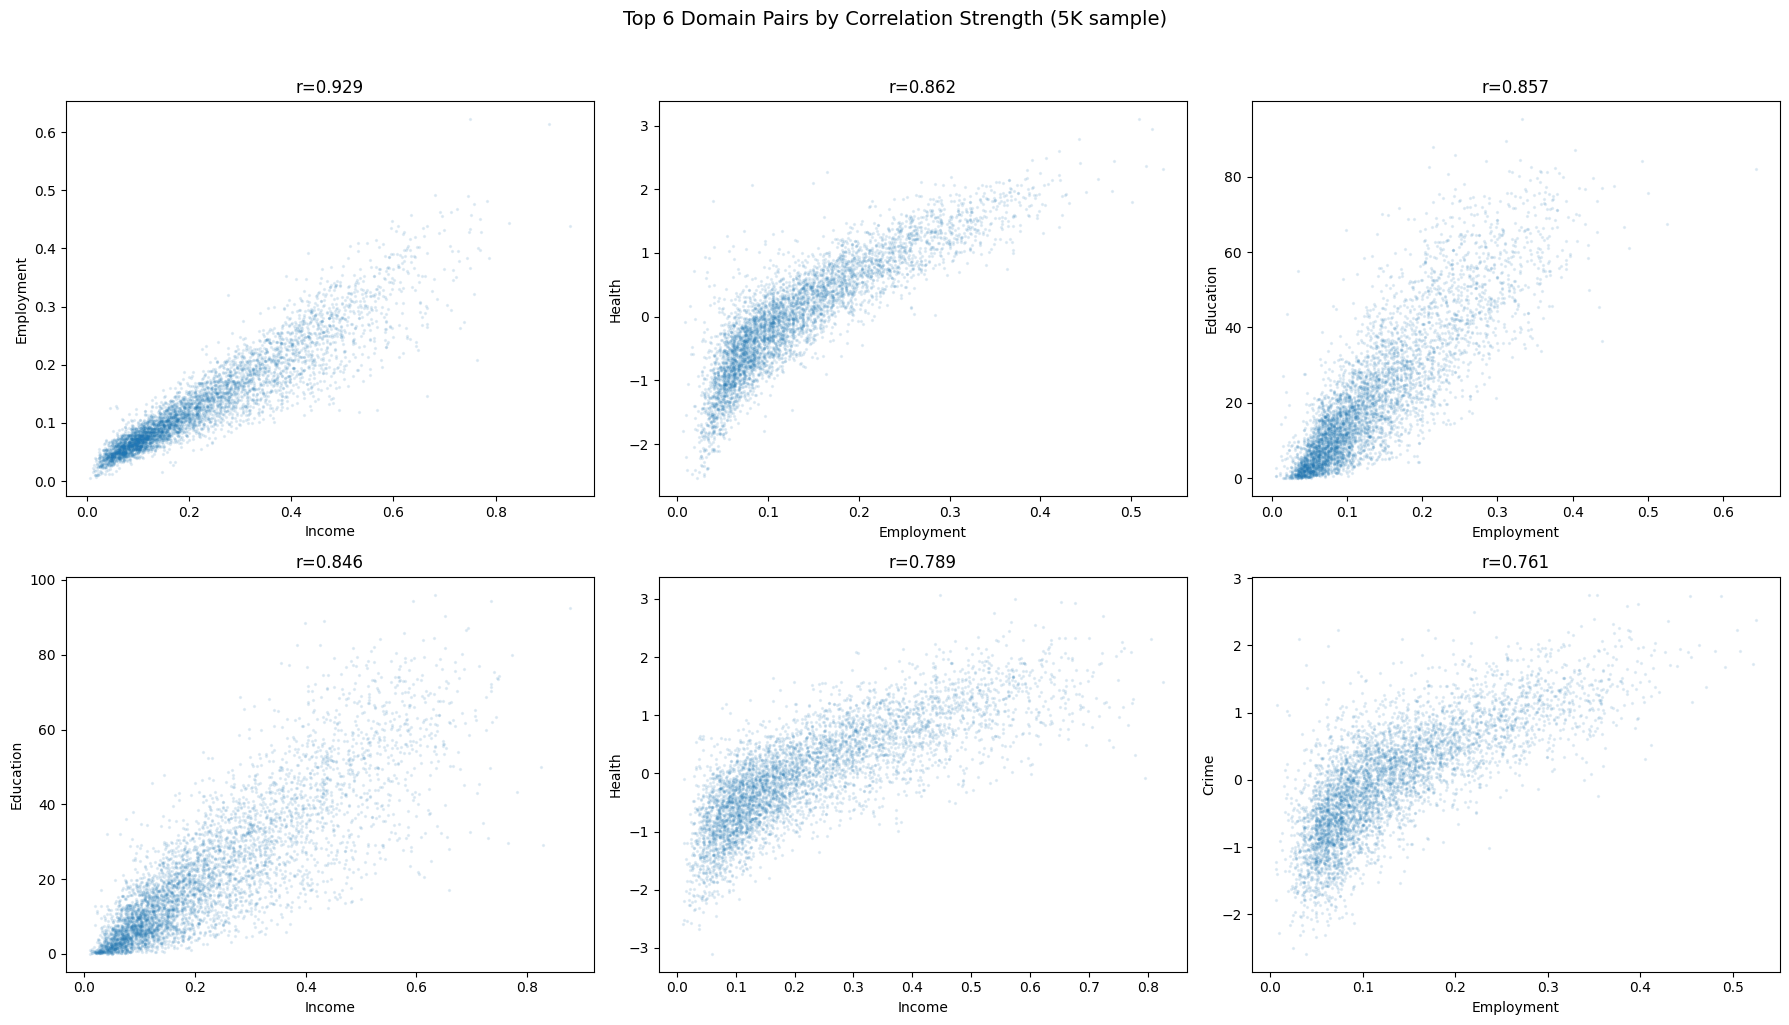

In [11]:
if len(domain_cols) >= 2:
    domain_df = imd[[c for c in domain_cols.values()]].copy()
    domain_df.columns = list(domain_cols.keys())

    # For each pair, show scatter
    from itertools import combinations
    pairs = list(combinations(domain_cols.keys(), 2))

    # Show the 6 most interesting pairs (highest and lowest correlations)
    pair_corrs = [(a, b, domain_df[a].corr(domain_df[b])) for a, b in pairs]
    pair_corrs.sort(key=lambda x: abs(x[2]), reverse=True)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    for i, (a, b, r) in enumerate(pair_corrs[:6]):
        sample_idx = np.random.choice(len(domain_df), min(5000, len(domain_df)), replace=False)
        axes[i].scatter(domain_df.iloc[sample_idx][a], domain_df.iloc[sample_idx][b], alpha=0.1, s=2)
        axes[i].set_xlabel(a)
        axes[i].set_ylabel(b)
        axes[i].set_title(f'r={r:.3f}')

    plt.suptitle('Top 6 Domain Pairs by Correlation Strength (5K sample)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

## 7. Population Columns — Who Lives in Deprived Areas?

In [12]:
pop_cols = [c for c in imd.columns if 'population' in c.lower() or 'Population' in c]
print("=== Population Columns in IMD ===")
for c in pop_cols:
    s = imd[c]
    print(f"\n{c}:")
    print(f"  Range: [{s.min()}, {s.max()}]")
    print(f"  Total: {s.sum():,}")
    print(f"  Mean per LSOA: {s.mean():.0f}")

    # Population in most vs least deprived
    if imd_decile_c:
        pop_by_decile = imd.groupby(imd_decile_c[0])[c].agg(['sum', 'mean', 'count'])
        print(f"\n  Population by IMD decile:")
        print(pop_by_decile.to_string())

=== Population Columns in IMD ===

Total population: mid 2022:
  Range: [940, 9512]
  Total: 57,112,129
  Mean per LSOA: 1692

  Population by IMD decile:
                                                                                        sum         mean  count
Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)                             
1                                                                                   5735377  1699.370963   3375
2                                                                                   5764540  1707.505924   3376
3                                                                                   5839393  1730.190519   3375
4                                                                                   5782194  1712.735190   3376
5                                                                                   5779606  1712.475852   3375
6                                                            

## 8. Summary — IMD Sub-Domain Mapping to Aequitas Factors

In [13]:
print("=" * 80)
print("  IMD SUB-DOMAIN → AEQUITAS FACTOR MAPPING")
print("=" * 80)
print("""
FACTOR 1 — Deprivation (IMD score/decile)
  → IMD composite score + rank + decile
  → All 7 domain scores for breakdown narrative

FACTOR 2 — Unemployment rate
  → Employment domain score (involuntary labour market exclusion)
  → Cross-validate with NOMIS TS066

FACTOR 3 — Car ownership
  → NO direct IMD column — use Census TS045
  → But: Barriers domain correlates (geographical access)

FACTOR 4 — Elderly population share
  → IDAOPI score (older people in income deprivation)
  → Cross-validate with Census TS007a age bands

FACTOR 5 — Income levels
  → Income domain score + IDACI + IDAOPI
  → Income = 22.5% of composite weight

FACTOR 6 — Ethnic composition
  → NO direct IMD column — use Census TS021
  → But: some domains show ethnic correlations

FACTOR 7 — Gender-adjusted accessibility (proxy)
  → Geographical Barriers sub-domain (distance to GP, school, post office, supermarket)
  → IDACI score (children in income deprivation = school/childcare access need)
  → Children & Young People sub-domain (education attainment)

FACTOR 8 — Urban/rural classification
  → NO direct IMD column — use RUC 2021
  → But: Geographical Barriers is STRONGLY correlated with rurality
""")

print("\n02d — IMD Sub-Domain Deep Dive: DONE")
print("56 columns examined. All sub-domains profiled and mapped to Aequitas factors.")

  IMD SUB-DOMAIN → AEQUITAS FACTOR MAPPING

FACTOR 1 — Deprivation (IMD score/decile)
  → IMD composite score + rank + decile
  → All 7 domain scores for breakdown narrative

FACTOR 2 — Unemployment rate
  → Employment domain score (involuntary labour market exclusion)
  → Cross-validate with NOMIS TS066

FACTOR 3 — Car ownership
  → NO direct IMD column — use Census TS045
  → But: Barriers domain correlates (geographical access)

FACTOR 4 — Elderly population share
  → IDAOPI score (older people in income deprivation)
  → Cross-validate with Census TS007a age bands

FACTOR 5 — Income levels
  → Income domain score + IDACI + IDAOPI
  → Income = 22.5% of composite weight

FACTOR 6 — Ethnic composition
  → NO direct IMD column — use Census TS021
  → But: some domains show ethnic correlations

FACTOR 7 — Gender-adjusted accessibility (proxy)
  → Geographical Barriers sub-domain (distance to GP, school, post office, supermarket)
  → IDACI score (children in income deprivation = school/chil